<h1>Importing Libraries<h1>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing



<h1>Loading Data<h1>

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:
print(df.shape)
print(df.sample(5))

(20640, 9)
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
3826   2.5842      18.0  3.677898   1.078167      2099.0  2.828841     34.20   
6520   2.4706      31.0  4.156593   1.068681      1396.0  3.835165     34.06   
6698   3.6572      26.0  4.160797   1.093023      3001.0  1.994020     34.14   
13726  1.3021      52.0  3.991632   0.974895       533.0  2.230126     34.06   
7051   3.1513      35.0  4.756208   1.083521      2241.0  5.058691     33.93   

       Longitude  MedHouseVal  
3826     -118.45        2.308  
6520     -118.03        1.706  
6698     -118.10        2.132  
13726    -117.18        1.000  
7051     -118.05        1.500  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


<h1>Preforming EDA<h1>

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
corr = df.corr()
corr["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

<p style=color:green><b>MedInc has highest correlation with MedHouseVal.As income is increasing, the value of house is also increasing with respect to it.<p>

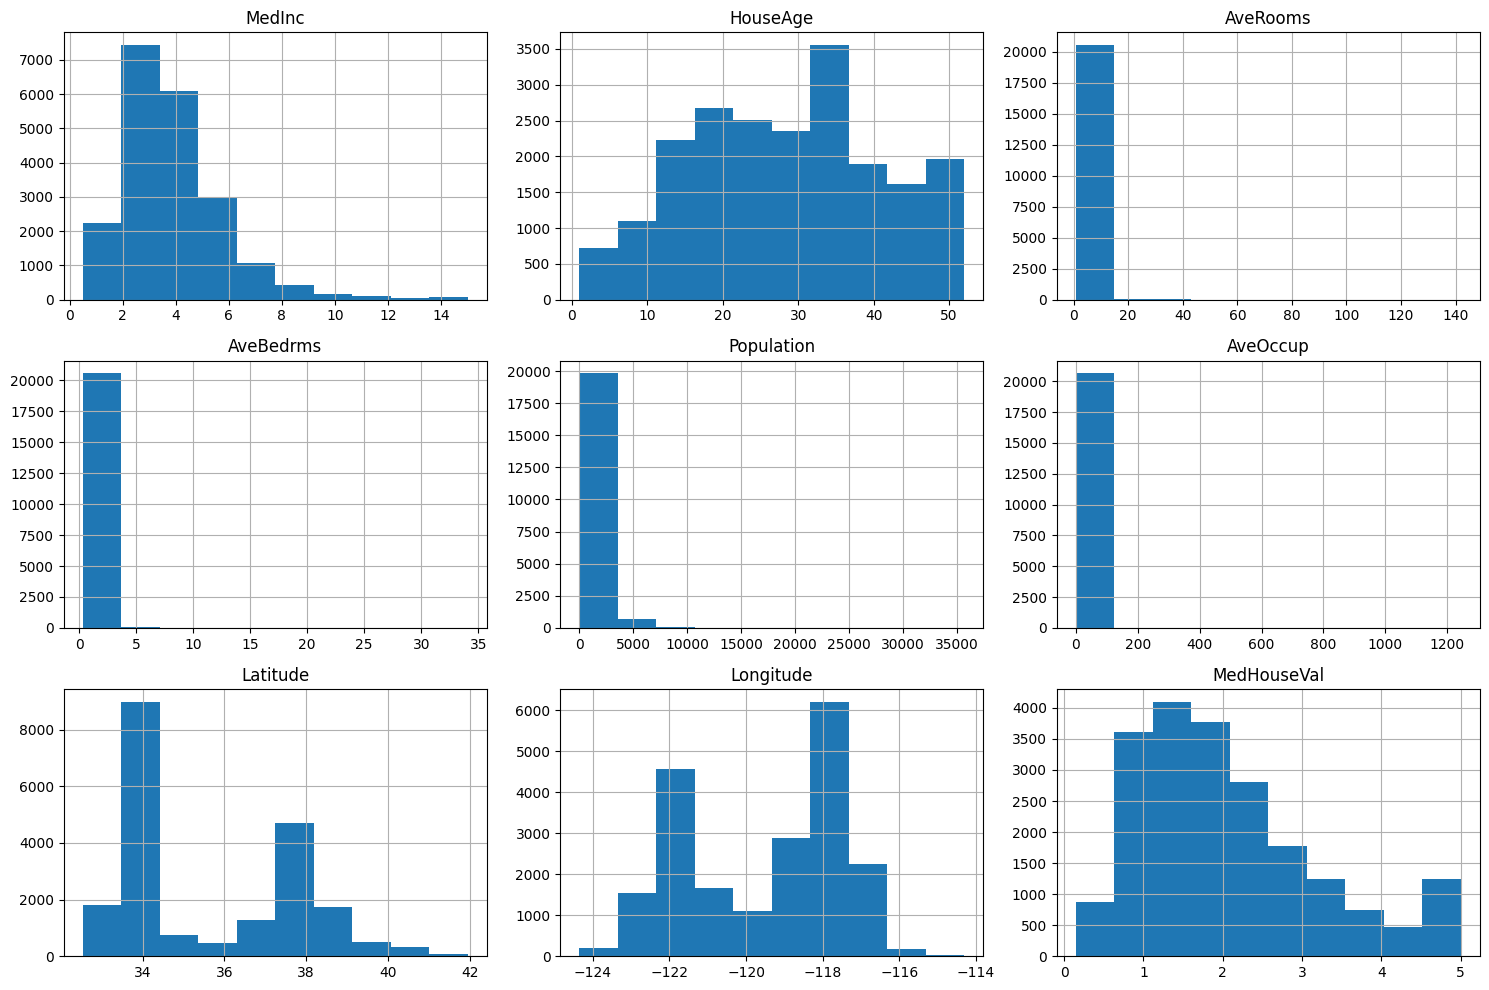

In [9]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

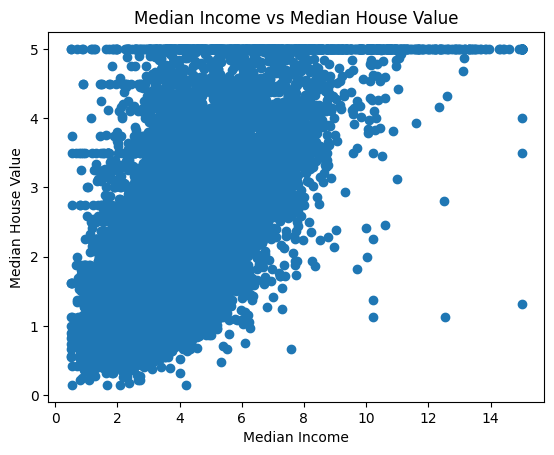

In [10]:

plt.scatter(df["MedInc"], df["MedHouseVal"])

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

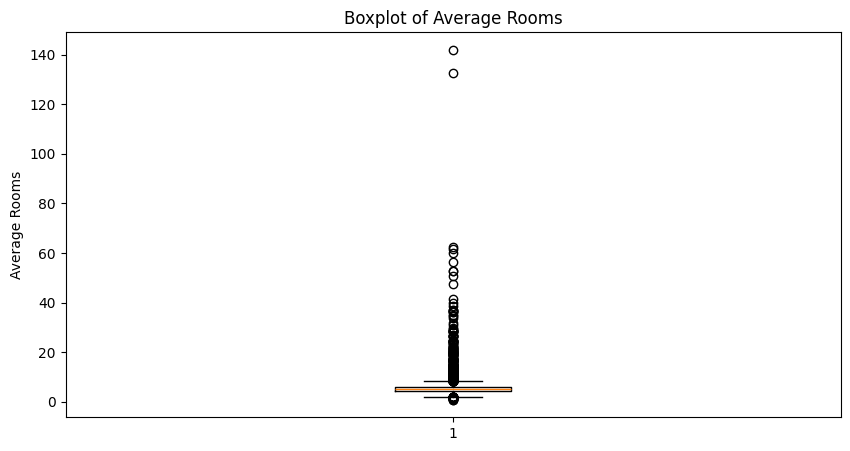

In [11]:
plt.figure(figsize=(10, 5))
plt.boxplot(df["AveRooms"])
plt.title("Boxplot of Average Rooms")
plt.ylabel("Average Rooms")
plt.show()

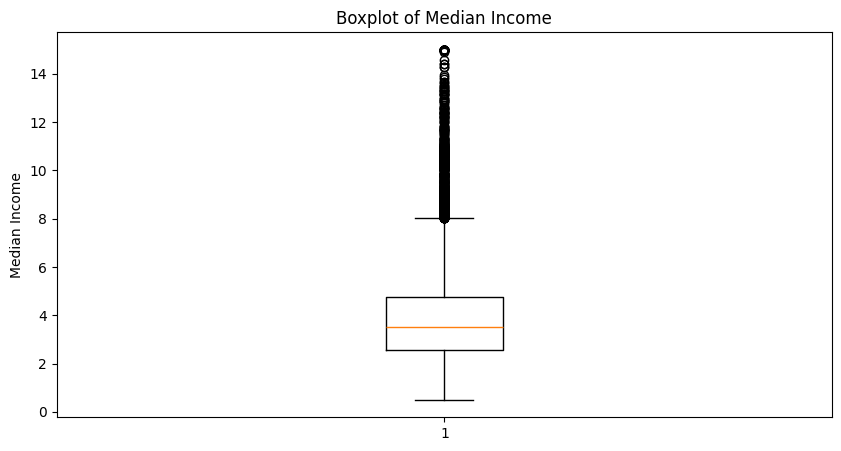

In [12]:
plt.figure(figsize=(10, 5))
plt.boxplot(df["MedInc"])
plt.title("Boxplot of Median Income")
plt.ylabel("Median Income")
plt.show()

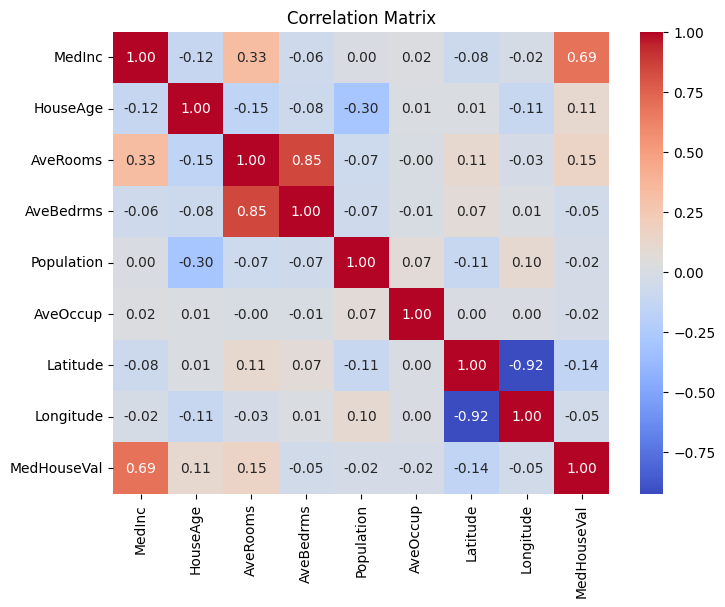

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

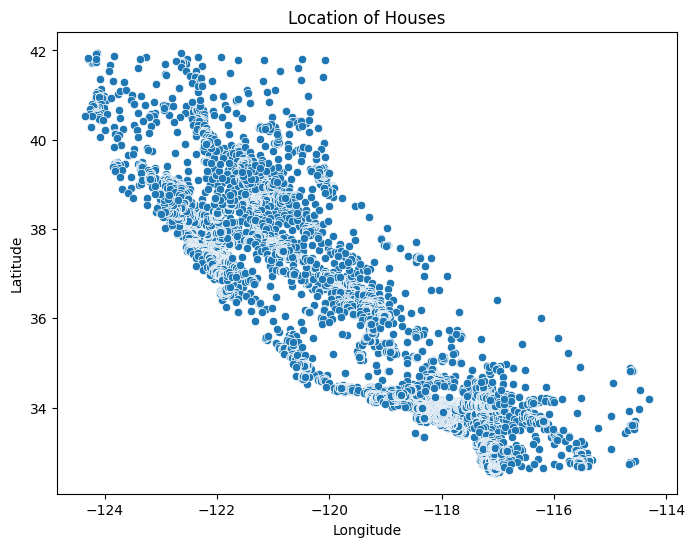

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Longitude", y="Latitude", data=df)
plt.title("Location of Houses")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

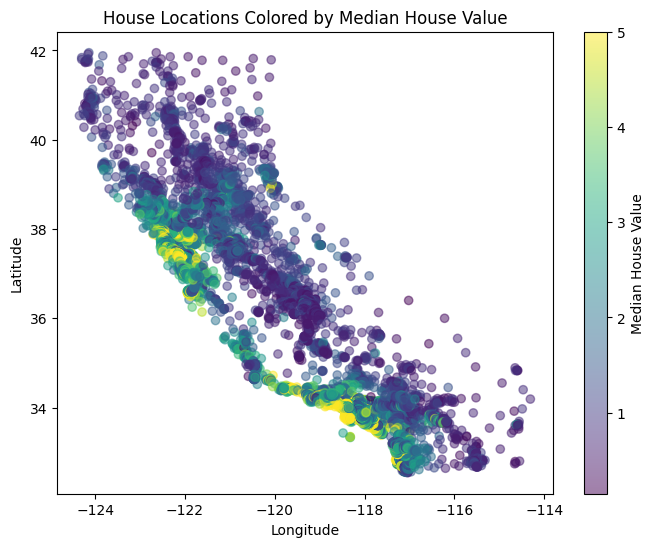

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Longitude"],df["Latitude"],c=df["MedHouseVal"],cmap="viridis",alpha=0.5)
plt.colorbar(label="Median House Value")
plt.title("House Locations Colored by Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<h1>Data Preprocessing<h1>

In [16]:
x=df.drop("MedHouseVal", axis=1)
y=df["MedHouseVal"]

<h4 style=color:green><b>Performing train_test_split<h4>

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


<h4 style=color:green><b>Feature Scaling<h4>

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

<h1>Model Training<h1>

<h3>Linear Regression Model<h3>

In [20]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(x_test_scaled)

In [22]:
results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
results.head(10)

,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


<h1>Model Evaluation<h1>

In [23]:
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rsme = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rsme}")
print(f"R-squared: {r2}")

Mean Absolute Error: 0.5332001304956564
Mean Squared Error: 0.5558915986952444
Root Mean Squared Error: 0.7455813830127764
R-squared: 0.5757877060324508


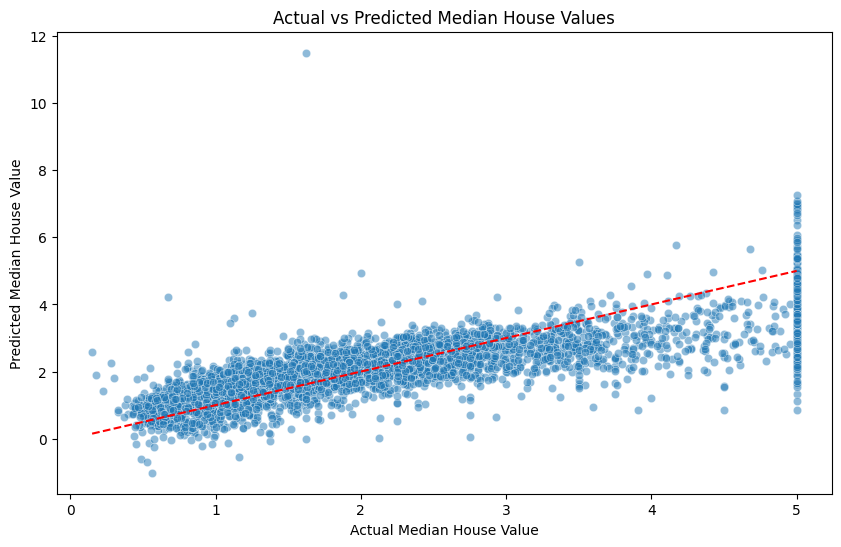

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
sns.lineplot(x=y_test, y=y_test, color='red', linestyle='--')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Median House Values")
plt.show()


<p style=color:green>It can be seen by these calculations and plot that the linear regression model is not the best fit for the prediction, as MAE and MSE both values are above 0.5 and  R-squared is 0.5757 meaning it explains about 60% of the variation in house prices.<p>

<h3>Decision Tree Model<h3>

In [25]:
from sklearn.tree import DecisionTreeRegressor

dtree_model = DecisionTreeRegressor(random_state=42)

dtree_model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [26]:
dtree_y_pred = dtree_model.predict(x_test)  

In [27]:
dtree_results = pd.DataFrame({"Actual": y_test, "Predicted": dtree_y_pred})
dtree_results.head(10)

,Actual,Predicted
20046,0.47700,0.41400
3024,0.45800,1.20300
15663,5.00001,5.00001
20484,2.18600,2.17000
9814,2.78000,2.25700
13311,1.58700,1.78700
7113,1.98200,2.21700
7668,1.57500,1.74000
18246,3.40000,2.77200
5723,4.46600,5.00001


In [28]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

print("Decision Tree Regressor Performance:")
dtree_mae = mean_absolute_error(y_test, dtree_y_pred)
dtree_mse = mean_squared_error(y_test, dtree_y_pred)
dtree_rmse = dtree_mse ** 0.5
dtree_r2 = r2_score(y_test, dtree_y_pred)

print(f"Mean Absolute Error: {dtree_mae}")
print(f"Mean Squared Error: {dtree_mse}")
print(f"Root Mean Squared Error: {dtree_rmse}")
print(f"R-squared: {dtree_r2}")

Decision Tree Regressor Performance:
Mean Absolute Error: 0.45467918846899225
Mean Squared Error: 0.495235205629094
Root Mean Squared Error: 0.7037294974840077
R-squared: 0.622075845135081


<p style=color:green>Decision tree is performing slightly better than linear regression model<p>

<h3>Random Forest Model<h3>

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=251, random_state=42)

rf_model.fit(x_train, y_train)

,n_estimators,251
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf_pred = rf_model.predict(x_test)

In [31]:
rf_results = pd.DataFrame({"Actual": y_test, "Predicted": rf_pred})
rf_results.head(10)

,Actual,Predicted
20046,0.47700,0.494406
3024,0.45800,0.735104
15663,5.00001,4.881636
20484,2.18600,2.534072
9814,2.78000,2.286506
13311,1.58700,1.646916
7113,1.98200,2.399813
7668,1.57500,1.658689
18246,3.40000,2.646945
5723,4.46600,4.891714


In [32]:
print("Random Forest Regressor Performance:")
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"Mean Absolute Error: {rf_mae}")
rf_mse = mean_squared_error(y_test, rf_pred)
print(f"Mean Squared Error: {rf_mse}")
rf_rmse = rf_mse ** 0.5
print(f"Root Mean Squared Error: {rf_rmse}")
rf_r2 = r2_score(y_test, rf_pred)
print(f"R-squared: {rf_r2}")


Random Forest Regressor Performance:
Mean Absolute Error: 0.3262211238862383
Mean Squared Error: 0.25316003750641186
Root Mean Squared Error: 0.5031501142863946
R-squared: 0.8068083768425829


<p style=color:green>Here we can clearly see that Random Forest performing better among all three models<p>

Important Features for prediction

In [33]:
imp_features=pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})

imp_features = imp_features.sort_values(by="Importance", ascending=False)
print(imp_features)

      Feature  Importance
0      MedInc    0.525809
5    AveOccup    0.137983
6    Latitude    0.088961
7   Longitude    0.088873
1    HouseAge    0.054093
2    AveRooms    0.044174
4  Population    0.030486
3   AveBedrms    0.029621


<p style=color:green>MedInc means income column is most important in prediction of house price<p>